# Student Performance Analysis & Prediction

# Objectives
The objective of this project is to analyze various factors affecting student performance and build a machine learning model to predict the final student performance based on different academic and personal attributes.



## Step 1: Import libraries.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2: Loading the Dataset

In this step, we load the student performance dataset into a Pandas DataFrame so that we can analyze and process it.

In [5]:
# load dataset
df = pd.read_csv("dataset/student_data.csv")

# display 5 rows
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Step 3: Understanding the Dataset

Before building a machine learning model, we need to understand the dataset's size, structure, data types, and any missing values.

In [6]:
# Shape of the dataset
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

df.info()
df.describe()

Shape of dataset: (395, 33)

Columns:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

Data Types:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health 

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## Step 4: Exploratory Data Analysis (EDA)

In this step, we will explore the dataset using summary statistics and visualizations to discover patterns and relationships.|

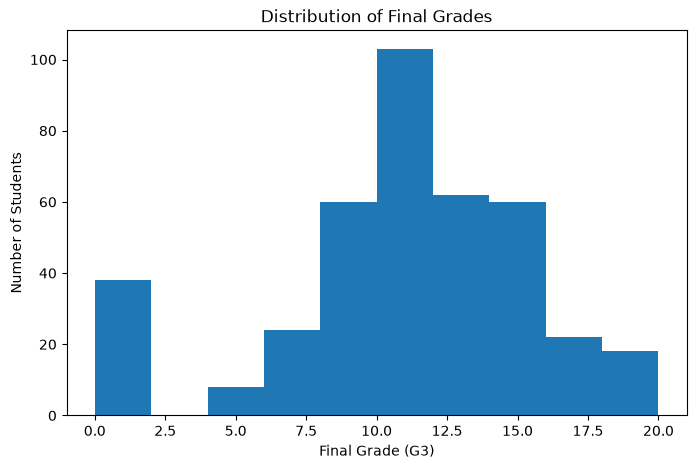

In [7]:
plt.figure(figsize=(8,5))

plt.hist(df["G3"], bins=10)

plt.title("Distribution of Final Grades")

plt.xlabel("Final Grade (G3)")

plt.ylabel("Number of Students")

plt.show()

### Observation

- Most students scored between **10 and 12.5**.
- Very few students scored below **5**.
- Very few students scored above **17**.
- The distribution suggests that most students achieved average performance.

## Relationship between Study Time and Final Grade


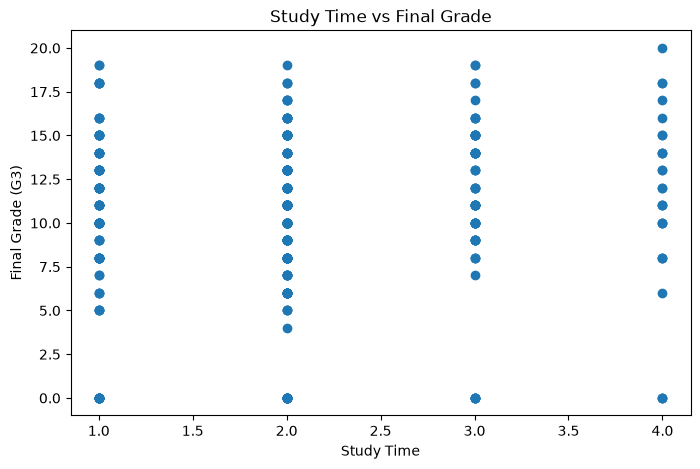

In [31]:
plt.figure(figsize=(8,5))

plt.scatter(df["studytime"], df["G3"])

plt.title("Study Time vs Final Grade")

plt.xlabel("Study Time")

plt.ylabel("Final Grade (G3)")

plt.show()

## Step 5: Correlation Analysis

In this step, we analyze the relationship between numerical features and the final grade (G3). This helps identify the most influential features for prediction.

In [9]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=["number"])

# Calculate correlation matrix
correlation = numeric_df.corr()

# Correlation with final grade
correlation["G3"].sort_values(ascending=False)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

## Step 6: Correlation Heatmap

A heatmap provides a visual representation of correlations between numerical features.

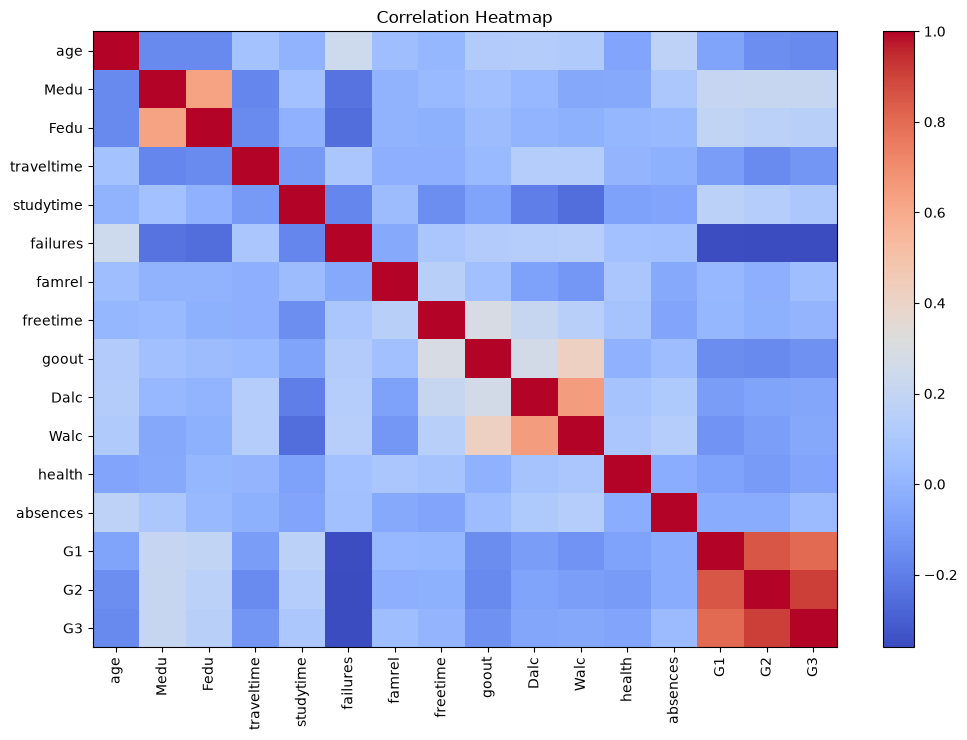

In [10]:
plt.figure(figsize=(12,8))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

## Step 7: Identify Categorical Features

Machine learning models cannot understand text directly. We first identify all categorical (object) columns in the dataset.

In [11]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print(categorical_columns)
len(categorical_columns)

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')


C:\Users\HP\AppData\Local\Temp\ipykernel_11432\1648806913.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


17

In [12]:
# Convert categorical columns into numerical columns

df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


In [13]:
'''
~ Why there is increase in column numbers?
By applying the One-Hot Encoding method, it converted  the categorical data into seperate 0/1 new columns, 
and other multiple category unique data is converted to several columns.
'''
print(df.shape)
print(df_encoded.shape)

(395, 33)
(395, 42)


## Step 8: Feature Selection

The target variable is G3 (final grade). All remaining columns will be used as input features for the machine learning model.

In [14]:
# Input features
X = df_encoded.drop("G3", axis=1)

# Target variable
y = df_encoded["G3"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (395, 41)
Target Shape: (395,)


## Step 9: Split the Dataset

In [15]:
# import machine learning library
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# Checking for the shape

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (316, 41)
X_test : (79, 41)
y_train: (316,)
y_test : (79,)


## Step 10: Train the Linear Regression Model

In this step, we train a Linear Regression model to predict the final grade (G3) using the selected features.

In [17]:
from sklearn.linear_model import LinearRegression

# create the model
model = LinearRegression()

# train the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](41,)","[-0.12, 0.09,-0.17,..., 0.38,-0.17,-0.39]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](41,)","['age','Medu','Fedu',...,'higher_yes','internet_yes','romantic_yes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.997
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,41
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(41)


## Step 11: Predict the Test Data

In [18]:
predictions = model.predict(X_test)
predictions[:10]

array([ 6.00160699, 11.52847844,  2.86643677,  8.79663116,  8.55310627,
       11.88964112, 19.09674195,  7.17307901,  7.4050707 , 12.31153657])

## Step 12: Compare Actual vs Predicted

In [19]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
78,10,6.001607
371,12,11.528478
248,5,2.866437
55,10,8.796631
390,9,8.553106
223,13,11.889641
42,18,19.096742
234,6,7.173079
316,0,7.405071
116,14,12.311537


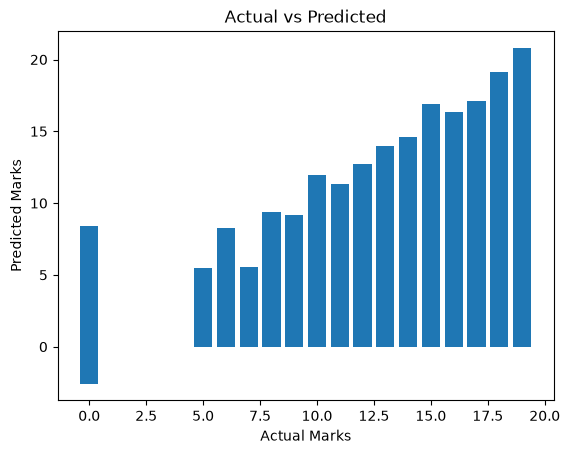

In [ ]:
# Visually Comparison 

plt.scatter(y_test, predictions)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")
plt.show()

## Step 13: Model Evaluation

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.6466656197147518
MSE: 5.656642833231225
RMSE: 2.3783697847961376
R2 Score: 0.7241341236974019


## Step 14: Feature Importance (Model Coefficients)

Linear Regression assigns a coefficient to every feature. These coefficients indicate how much each feature influences the predicted final grade (G3).

In [22]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)
# Top 10 positive factors
print("Top 10 positive factors:\n")
print(coefficients.head(10))

# Top 10 negative factors
print("\nTop 10 negative factors:\n")
print(coefficients.tail(10))

Top 10 positive factors:

          Feature  Coefficient
14             G2     0.957772
33  schoolsup_yes     0.785652
24    Fjob_health     0.481242
38     higher_yes     0.375377
16          sex_M     0.374410
6          famrel     0.314962
29   reason_other     0.304973
13             G1     0.211699
25     Fjob_other     0.206441
34     famsup_yes     0.203656

Top 10 negative factors:

              Feature  Coefficient
9                Dalc    -0.185509
30  reason_reputation    -0.221694
37        nursery_yes    -0.236861
21         Mjob_other    -0.237195
5            failures    -0.285781
26      Fjob_services    -0.294762
40       romantic_yes    -0.390353
20        Mjob_health    -0.463244
36     activities_yes    -0.517500
28        reason_home    -0.611901


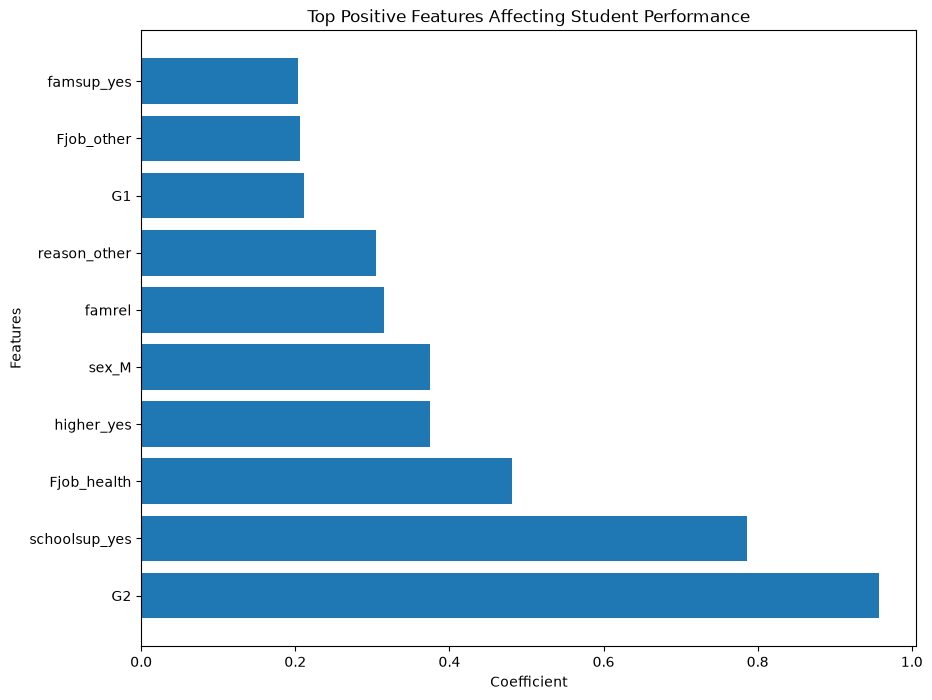

In [23]:
# Visualization of feature importance
plt.figure(figsize=(10,8))

top_features = coefficients.head(10)

plt.barh(top_features["Feature"], top_features["Coefficient"])

plt.xlabel("Coefficient")

plt.ylabel("Features")

plt.title("Top Positive Features Affecting Student Performance")

plt.show()

## Step 14: Understand the mistake

In [24]:
residuals = y_test - predictions

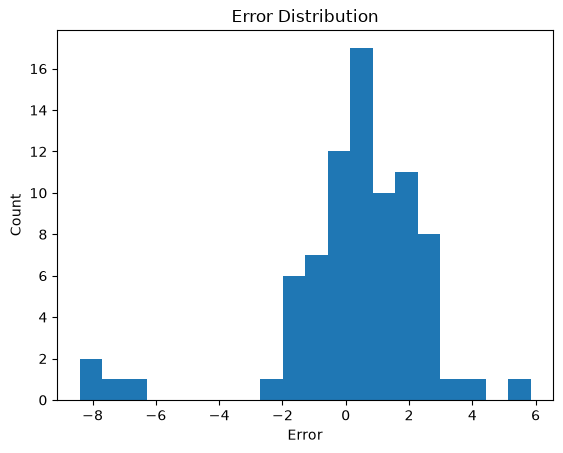

In [25]:
import matplotlib.pyplot as plt

plt.hist(residuals, bins=20)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()

## Save Model

In [26]:
import joblib

joblib.dump(model, "student_performance_model.pkl")

['student_performance_model.pkl']

# Conclusion

This project successfully developed an end-to-end Data Science solution for analyzing and predicting student academic performance using Machine Learning.

The project began with data loading, cleaning, and exploratory data analysis (EDA) to understand the dataset and identify relationships between different student attributes and their final grades. Categorical features were converted into numerical values using One-Hot Encoding, making the dataset suitable for machine learning algorithms.

A Linear Regression model was trained to predict students' final grades (G3). The model achieved the following performance:

- Mean Absolute Error (MAE): **1.65**
- Mean Squared Error (MSE): **5.66**
- Root Mean Squared Error (RMSE): **2.38**
- R² Score: **0.724**

These results indicate that the model predicts student performance with good accuracy, with an average prediction error of approximately 1.65 marks and explaining about 72.4% of the variation in students' final grades.

Feature coefficient analysis showed that the **G2 (Second Period Grade)** was the most influential predictor of the final grade, followed by factors such as school support, family support, and the student's intention to pursue higher education. Residual analysis indicated that most prediction errors were concentrated around zero, suggesting that the model performs consistently without significant bias toward overprediction or underprediction.

Overall, this project demonstrates the complete Data Science workflow, including data preprocessing, exploratory data analysis, feature engineering, model building, evaluation, and interpretation of results. It also provides a strong foundation for future improvements such as testing advanced machine learning algorithms, performing hyperparameter tuning, and deploying the model as a web application using Streamlit.